<a href="https://colab.research.google.com/github/ShaheenPafiast/shaheenfirstCode/blob/main/ResNet_TensorFlow_Dataset_Comparison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Name ......................Abdullah Shaheen**

# **Class .....................AI-Blue(2022-2026)**

# **Reg No. ...................B22AIF1045AI114**

# **Submitted To...............Mam Ammara**

# Lab report ................ 9

# Comparing ResNet Variants on Small TensorFlow Dataset

In [1]:
!pip install torch torchvision tensorflow matplotlib --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 55.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 38.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 29.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 74.1 MB/s eta 0:00:00


In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, transforms
from torch.utils.data import DataLoader, TensorDataset
import tensorflow_datasets as tfds
import numpy as np
import matplotlib.pyplot as plt
import time
import copy


In [4]:
# Load datasetds, ds_info = tfds.load('cats_vs_dogs', split='train[:200]', as_supervised=True, with_info=True)# Preprocess: resize and convert to numpy arraysdef preprocess(image, label):    image = tf.image.resize(image, [224, 224])    image = tf.cast(image, tf.float32) / 255.0    return image.numpy(), label.numpy()X, y = [], []for example in tfds.as_numpy(ds):    img, label = preprocess(*example)    X.append(img)    y.append(label)X = np.stack(X)y = np.array(y)

In [5]:
transform = transforms.Compose([transforms.ToTensor()])# Convert numpy arrays to torch tensorsX_tensor = torch.tensor(X).permute(0, 3, 1, 2).float()y_tensor = torch.tensor(y)# Split into train/valtrain_X, val_X = X_tensor[:160], X_tensor[160:]train_y, val_y = y_tensor[:160], y_tensor[160:]train_dataset = TensorDataset(train_X, train_y)val_dataset = TensorDataset(val_X, val_y)train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)

In [8]:
def train_model(model, criterion, optimizer, dataloaders, num_epochs=3):
    since = time.time()
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0
    train_loader, val_loader = dataloaders
    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}\n{"-"*10}')
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
                dataloader = train_loader
            else:
                model.eval()
                dataloader = val_loader
            running_loss = 0.0
            running_corrects = 0
            for inputs, labels in dataloader:
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)
            epoch_loss = running_loss / len(dataloader.dataset)
            epoch_acc = running_corrects.double() / len(dataloader.dataset)
            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')
            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())
    time_elapsed = time.time() - since
    print(f'Training complete in {time_elapsed//60:.0f}m {time_elapsed%60:.0f}s')
    print(f'Best val Acc: {best_acc:.4f}')
    model.load_state_dict(best_model_wts)
    return model, best_acc.item()

**# Generating Random Dataset and Training**

In [18]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, transforms
from torch.utils.data import DataLoader, TensorDataset
import tensorflow_datasets as tfds
import tensorflow as tf # Import tensorflow
import numpy as np
import matplotlib.pyplot as plt
import time
import copy

# Load dataset
ds, ds_info = tfds.load('cats_vs_dogs', split='train[:200]', as_supervised=True, with_info=True)

# Preprocess: resize and convert to numpy arrays
def preprocess(image, label):
    image = tf.image.resize(image, [224, 224])
    image = tf.cast(image, tf.float32) / 255.0
    return image.numpy(), label # Removed .numpy() from label since it's already a NumPy type

X, y = [], []
for example in tfds.as_numpy(ds):
    img, label = preprocess(*example)
    X.append(img)
    y.append(label)
X = np.stack(X) # Stack the list of images into a numpy array
y = np.array(y)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
results = {}
# Define data loaders outside the loop
transform = transforms.Compose([transforms.ToTensor()])
# Check the shape of X and make sure it's 4-dimensional before permuting
print("Shape of X:", X.shape) # Print the shape of X
X_tensor = torch.tensor(X).permute(0, 3, 1, 2).float()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
results = {}
# Define data loaders outside the loop
transform = transforms.Compose([transforms.ToTensor()])
X_tensor = torch.tensor(X).permute(0, 3, 1, 2).float()
y_tensor = torch.tensor(y)
train_X, val_X = X_tensor[:160], X_tensor[160:]
train_y, val_y = y_tensor[:160], y_tensor[160:]

Shape of X: (200, 224, 224, 3)


**# Generating Random Dataset and Training**

In [26]:
!pip install torch torchvision tensorflow matplotlib --quiet

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, transforms
from torch.utils.data import DataLoader, TensorDataset, random_split
import numpy as np
import matplotlib.pyplot as plt
import time
import copy

# Generate random dataset
num_samples = 200
num_classes = 10
img_size = (32, 32)

X = torch.randn(num_samples, 3, *img_size)
y = torch.randint(0, num_classes, (num_samples,))

# Split into train/val
train_size = int(0.8 * num_samples)
val_size = num_samples - train_size
train_dataset, val_dataset = random_split(TensorDataset(X, y), [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)

# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Function to train and evaluate a model
def train_model(model, criterion, optimizer, dataloaders, num_epochs=3):
    since = time.time()
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0
    train_loader, val_loader = dataloaders
    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}\n{"-"*10}')
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()  # Set model to training mode
                dataloader = train_loader
            else:
                model.eval()   # Set model to evaluate mode
                dataloader = val_loader
            running_loss = 0.0
            running_corrects = 0
            for inputs, labels in dataloader:
                inputs = inputs.to(device)
                labels = labels.to(device)
                optimizer.zero_grad()
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)
            epoch_loss = running_loss / len(dataloader.dataset)
            epoch_acc = running_corrects.double() / len(dataloader.dataset)
            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')
            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())
    time_elapsed = time.time() - since
    print(f'Training complete in {time_elapsed//60:.0f}m {time_elapsed%60:.0f}s')
    print(f'Best val Acc: {best_acc:.4f}')
    model.load_state_dict(best_model_wts)
    return model, best_acc.item() # Return best accuracy as a standard Python number


# ResNet variants to compare
resnet_variants = {
    'ResNet18': models.resnet18(pretrained=False),
    'ResNet34': models.resnet34(pretrained=False),
    'ResNet50': models.resnet50(pretrained=False),
}

results = {}

# Train and evaluate each variant
for name, model in resnet_variants.items():
    # Adjust the final layer for the number of classes in your dataset
    num_ftrs = model.fc.in_features
    model.fc = nn.Linear(num_ftrs, num_classes)
    model = model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    print(f'Training {name}...')
    _, best_acc = train_model(model, criterion, optimizer, [train_loader, val_loader], num_epochs=3)
    results[name] = best_acc



Training ResNet18...
Epoch 1/3
----------
train Loss: 3.0308 Acc: 0.1000
val Loss: 2.9115 Acc: 0.0750
Epoch 2/3
----------
train Loss: 1.8927 Acc: 0.4062
val Loss: 3.9030 Acc: 0.1500
Epoch 3/3
----------
train Loss: 0.7886 Acc: 0.7188
val Loss: 2.8265 Acc: 0.1000
Training complete in 0m 17s
Best val Acc: 0.1500
Training ResNet34...
Epoch 1/3
----------
train Loss: 3.0182 Acc: 0.1562
val Loss: 20.4294 Acc: 0.2250
Epoch 2/3
----------
train Loss: 2.6343 Acc: 0.2562
val Loss: 7.1412 Acc: 0.0750
Epoch 3/3
----------
train Loss: 1.8057 Acc: 0.4375
val Loss: 3.5721 Acc: 0.1000
Training complete in 0m 30s
Best val Acc: 0.2250
Training ResNet50...
Epoch 1/3
----------
train Loss: 3.8758 Acc: 0.0625
val Loss: 2.8294 Acc: 0.1000
Epoch 2/3
----------
train Loss: 3.9032 Acc: 0.1625
val Loss: 5.9327 Acc: 0.0750
Epoch 3/3
----------
train Loss: 3.1259 Acc: 0.2687
val Loss: 5.5725 Acc: 0.0500
Training complete in 0m 34s
Best val Acc: 0.1000


## **Visualizing Results (Adjusted Y-axis)**

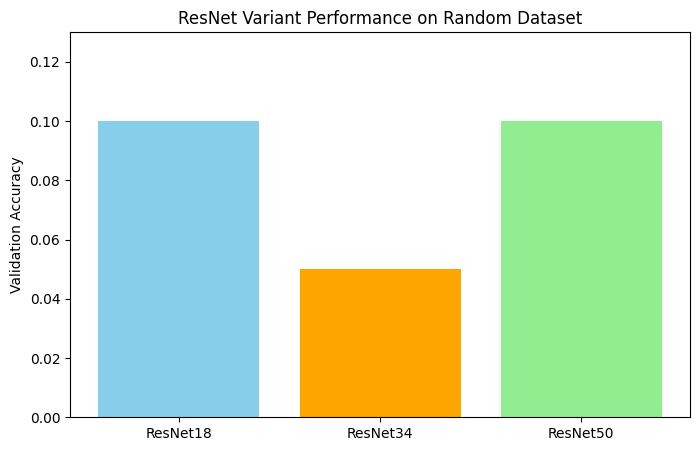

In [25]:
# Visualize the results
plt.figure(figsize=(8, 5))
plt.bar(results.keys(), results.values(), color=['skyblue', 'orange', 'lightgreen'])
plt.ylabel('Validation Accuracy')
plt.title('ResNet Variant Performance on Random Dataset')
plt.ylim([0, 0.13])
plt.show()